In [4]:
import pandas as pd
import sqlite3

In [5]:
conn = sqlite3.connect("dineiq.db")

In [7]:
df_clean=pd.read_csv("cleaned_zomato.csv")

In [8]:
df_clean.to_sql("restaurants", conn, if_exists="replace", index=False)

9034

In [10]:
print(df_clean.columns)

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)', 'cost_segment'],
      dtype='object')


In [11]:
query_1 = """
SELECT
    location,
    COUNT(*) AS hidden_gem_count,
    ROUND(AVG(rate), 2) AS avg_rating,
    ROUND(AVG([approx_cost(for two people)]), 2) AS avg_cost

FROM restaurants

WHERE rate >= 4.0
  AND votes < 200
  AND book_table = 'Yes'

GROUP BY location

ORDER BY hidden_gem_count DESC
LIMIT 10;
"""

hidden_gems_location = pd.read_sql_query(query_1, conn)

hidden_gems_location


,location,hidden_gem_count,avg_rating,avg_cost
0,Whitefield,8,4.11,400.00
1,Indiranagar,7,4.14,500.00
2,Ulsoor,5,4.14,400.00
3,Sarjapur Road,4,4.45,475.00
4,Electronic City,4,4.08,400.00
5,Richmond Road,3,4.37,400.00
6,Race Course Road,3,4.07,400.00
7,Marathahalli,3,4.13,533.33
8,MG Road,3,4.17,533.33
9,Jayanagar,3,4.13,700.00


In [12]:
query_2 = """
SELECT
    book_table,
    COUNT(*) AS restaurant_count,
    ROUND(AVG(rate), 2) AS avg_rating,
    ROUND(AVG(votes), 2) AS avg_votes
FROM restaurants
GROUP BY book_table;
"""

booking_vs_rating = pd.read_sql_query(query_2, conn)

booking_vs_rating

,book_table,restaurant_count,avg_rating,avg_votes
0,No,8119,3.57,157.71
1,Yes,915,4.12,1017.53


In [16]:
query_3 = """
SELECT
    CASE
        WHEN [approx_cost(for two people)] < 500 THEN 'Budget'
        WHEN [approx_cost(for two people)] BETWEEN 500 AND 1000 THEN 'Mid-range'
        ELSE 'Premium'
    END AS price_segment,

    COUNT(*) AS restaurant_count

FROM restaurants

GROUP BY price_segment

ORDER BY restaurant_count DESC;
"""

price_segments = pd.read_sql_query(query_3, conn)

price_segments

,price_segment,restaurant_count
0,Budget,6063
1,Mid-range,2971


In [17]:
query_4 = """
SELECT
    cuisines,
    COUNT(*) AS hidden_gem_count,
    ROUND(AVG(rate), 2) AS avg_rating

FROM restaurants

WHERE rate >= 4.0
  AND votes < 200
  AND book_table = 'Yes'

GROUP BY cuisines

ORDER BY hidden_gem_count DESC
LIMIT 10;
"""

top_hidden_cuisines = pd.read_sql_query(query_4, conn)

top_hidden_cuisines

,cuisines,hidden_gem_count,avg_rating
0,Continental,3,4.13
1,"North Indian, Biryani",2,4.10
2,North Indian,2,4.10
3,Japanese,2,4.30
4,Italian,2,4.00
5,"Sushi, Continental, Pizza, Italian, Asian",1,4.10
6,"South Indian, North Indian, Continental, European",1,4.10
7,"South Indian, North Indian, Chinese, Biryani",1,4.00
8,"South Indian, North Indian, Chinese, Beverages",1,4.10
9,"South Indian, Kerala, Andhra, Biryani, Chettin...",1,4.20


In [18]:
query_5 = """
SELECT
    location,

    COUNT(*) AS total_restaurants,

    SUM(
        CASE
            WHEN book_table = 'Yes' THEN 1
            ELSE 0
        END
    ) AS bookable_restaurants,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN book_table = 'Yes' THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS booking_percentage

FROM restaurants

GROUP BY location

HAVING total_restaurants >= 10

ORDER BY booking_percentage DESC
LIMIT 10;
"""

expansion_locations = pd.read_sql_query(query_5, conn)

expansion_locations

,location,total_restaurants,bookable_restaurants,booking_percentage
0,Sankey Road,12,6,50.00
1,Koramangala 3rd Block,19,8,42.11
2,Lavelle Road,52,21,40.38
3,MG Road,81,29,35.80
4,Race Course Road,29,10,34.48
5,Sadashiv Nagar,28,8,28.57
6,St. Marks Road,34,9,26.47
7,Church Street,53,14,26.42
8,Koramangala 4th Block,103,26,25.24
9,Cunningham Road,47,11,23.40


## SQL Analysis Summary

Using SQLite queries on the cleaned Zomato Bangalore dataset, I identified:

- High-density hidden gem clusters across specific Bangalore locations
- Strong rating patterns among table-booking enabled restaurants
- Dominant pricing segments affecting restaurant discovery
- Under-discovered cuisine categories with high customer satisfaction
- High booking-adoption areas suitable for Dineout expansion

This analysis demonstrates how SQL can be used for product decision-making,
market expansion analysis, and recommendation-system thinking.

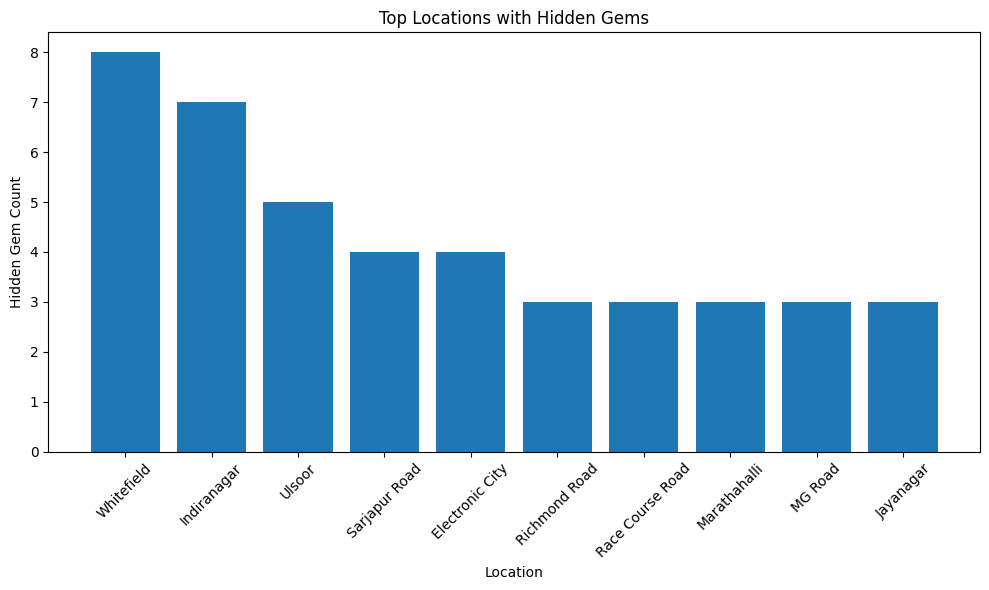

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    hidden_gems_location["location"],
    hidden_gems_location["hidden_gem_count"]
)

plt.xticks(rotation=45)
plt.xlabel("Location")
plt.ylabel("Hidden Gem Count")
plt.title("Top Locations with Hidden Gems")

plt.tight_layout()
plt.show()

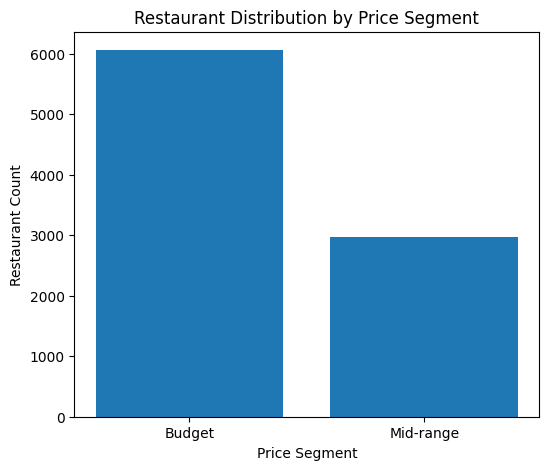

In [20]:
plt.figure(figsize=(6,5))

plt.bar(
    price_segments["price_segment"],
    price_segments["restaurant_count"]
)

plt.xlabel("Price Segment")
plt.ylabel("Restaurant Count")
plt.title("Restaurant Distribution by Price Segment")

plt.show()

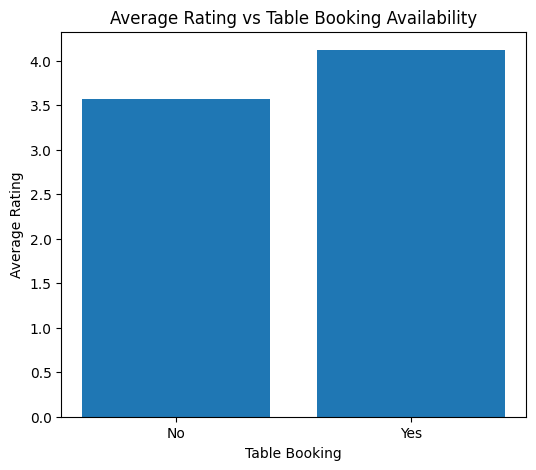

In [21]:
plt.figure(figsize=(6,5))

plt.bar(
    booking_vs_rating["book_table"],
    booking_vs_rating["avg_rating"]
)

plt.xlabel("Table Booking")
plt.ylabel("Average Rating")
plt.title("Average Rating vs Table Booking Availability")

plt.show()